# Standard Dietary Recommendations Analysis

วิเคราะห์คำแนะนำการกินตามมาตรฐานสุขภาพ พร้อม export ตาราง knowledge สำหรับใช้ต่อในโปรเจกต์ Welly

สิ่งที่ notebook นี้ทำ:
- โหลด dataset คำแนะนำโภชนาการรายบุคคล
- สรุปมาตรฐานอ้างอิงจาก `media.pdf` และ `DGA.pdf`
- export knowledge tables ไปที่ `data/knowledge/`
- ทำ quick EDA กับชุดข้อมูลอาหารเพื่อเช็ก sanity ของข้อมูล


In [1]:
from pathlib import Path
import json

import numpy as np
import pandas as pd

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

try:
    from IPython.display import display
except ImportError:
    def display(obj):
        print(obj)

try:
    import seaborn as sns
    if plt is not None:
        sns.set_theme(style="whitegrid")
except ImportError:
    sns = None

pd.set_option("display.max_columns", None)
if plt is not None:
    plt.rcParams["figure.figsize"] = (10, 6)


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "data").exists():
            return candidate
    raise FileNotFoundError("ไม่พบโฟลเดอร์ data/ ใน current directory หรือ parent directories")


def dataframe_to_records(df: pd.DataFrame) -> list[dict]:
    return df.astype(object).where(pd.notna(df), None).to_dict(orient="records")


PROJECT_ROOT = find_project_root()
DATA_DIR = PROJECT_ROOT / "data"
KNOWLEDGE_DIR = DATA_DIR / "knowledge"
KNOWLEDGE_DIR.mkdir(parents=True, exist_ok=True)

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"KNOWLEDGE_DIR: {KNOWLEDGE_DIR}")


PROJECT_ROOT: /Users/madba/Pictures/GitTast/Welly-AI-Final-Project-
DATA_DIR: /Users/madba/Pictures/GitTast/Welly-AI-Final-Project-/data
KNOWLEDGE_DIR: /Users/madba/Pictures/GitTast/Welly-AI-Final-Project-/data/knowledge


## 1) Personalized Diet Recommendation Overview

ส่วนนี้สรุป distribution เบื้องต้นของคำแนะนำพลังงานและสารอาหารที่ระบบแนะนำให้แต่ละคน


In [2]:
diet_path = DATA_DIR / "Personalized_Diet_Recommendations.csv"
diet_recommendations = pd.read_csv(diet_path)

diet_recommendations["Age_Group"] = pd.cut(
    diet_recommendations["Age"],
    bins=[0, 18, 35, 50, 65, 100],
    labels=["<18", "18-35", "35-50", "50-65", "65+"],
    include_lowest=True,
)

print(
    f"Loaded {diet_recommendations.shape[0]:,} rows x {diet_recommendations.shape[1]:,} columns "
    f"from {diet_path.name}"
)
display(diet_recommendations.head())


Loaded 5,000 rows x 31 columns from Personalized_Diet_Recommendations.csv


,Patient_ID,Age,Gender,Height_cm,Weight_kg,BMI,Chronic_Disease,Blood_Pressure_Systolic,Blood_Pressure_Diastolic,Cholesterol_Level,Blood_Sugar_Level,Genetic_Risk_Factor,Allergies,Daily_Steps,Exercise_Frequency,Sleep_Hours,Alcohol_Consumption,Smoking_Habit,Dietary_Habits,Caloric_Intake,Protein_Intake,Carbohydrate_Intake,Fat_Intake,Preferred_Cuisine,Food_Aversions,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats,Recommended_Meal_Plan,Age_Group
0,P00001,56,Other,163,66,24.84,NaN,175,75,219,124,No,NaN,11452,5,7.6,No,Yes,Vegetarian,2593,105,179,143,Western,NaN,2150,108,139,145,High-Protein Diet,50-65
1,P00002,69,Female,171,114,38.99,NaN,155,72,208,72,No,NaN,12962,1,6.3,Yes,No,Vegetarian,1852,69,315,75,Mediterranean,NaN,1527,74,266,80,Balanced Diet,65+
2,P00003,46,Female,172,119,40.22,NaN,137,101,171,145,No,Gluten Intolerance,7898,3,9.9,No,No,Vegetarian,2737,183,103,148,Western,Sweet,2359,180,145,143,High-Protein Diet,35-50
3,P00004,32,Female,197,118,30.41,NaN,148,91,258,235,No,Nut Allergy,6602,5,4.2,No,No,Vegetarian,3289,135,371,120,Western,NaN,2858,137,378,135,High-Protein Diet,18-35
4,P00005,60,Female,156,109,44.79,Hypertension,160,109,260,248,Yes,NaN,9810,2,9.0,No,No,Regular,2405,167,298,48,Indian,Spicy,1937,166,317,56,High-Protein Diet,50-65


In [4]:
target_cols = [
    "Recommended_Calories",
    "Recommended_Protein",
    "Recommended_Carbs",
    "Recommended_Fats",
]

avg_targets_by_age = (
    diet_recommendations.groupby("Age_Group", observed=False)[target_cols]
    .mean()
    .round(1)
)

avg_targets_by_gender = (
    diet_recommendations.groupby("Gender")[target_cols]
    .mean()
    .round(1)
)

meal_plan_counts = diet_recommendations["Recommended_Meal_Plan"].value_counts()

display(avg_targets_by_age)
display(avg_targets_by_gender)
display(meal_plan_counts.rename_axis("Recommended_Meal_Plan").to_frame("count"))


,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats
Age_Group,,,,
<18,2105.5,128.4,248.4,83.8
18-35,2017.1,128.4,250.5,87.9
35-50,2051.2,132.3,249.9,88.7
50-65,2046.1,127.5,246.1,89.6
65+,2070.4,129.1,246.5,90.5


,Recommended_Calories,Recommended_Protein,Recommended_Carbs,Recommended_Fats
Gender,,,,
Female,2065.0,127.8,248.1,89.0
Male,2030.8,129.5,248.2,88.2
Other,2042.5,130.6,248.6,89.9


,count
Recommended_Meal_Plan,
Low-Fat Diet,1313
High-Protein Diet,1255
Balanced Diet,1250
Low-Carb Diet,1182


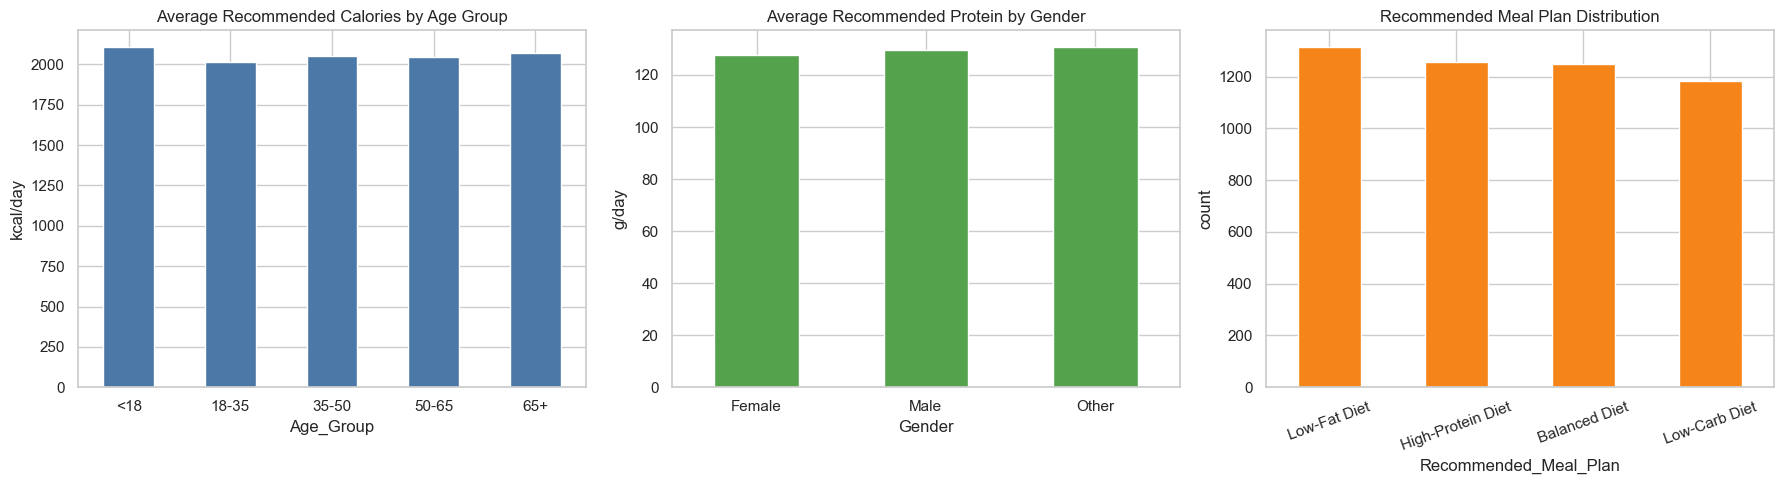

In [5]:
if plt is None:
    print("matplotlib is not installed; skipping charts.")
else:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    avg_targets_by_age["Recommended_Calories"].plot(
        kind="bar",
        ax=axes[0],
        color="#4C78A8",
        rot=0,
    )
    axes[0].set_title("Average Recommended Calories by Age Group")
    axes[0].set_ylabel("kcal/day")

    avg_targets_by_gender["Recommended_Protein"].plot(
        kind="bar",
        ax=axes[1],
        color="#54A24B",
        rot=0,
    )
    axes[1].set_title("Average Recommended Protein by Gender")
    axes[1].set_ylabel("g/day")

    meal_plan_counts.plot(
        kind="bar",
        ax=axes[2],
        color="#F58518",
    )
    axes[2].set_title("Recommended Meal Plan Distribution")
    axes[2].set_ylabel("count")
    axes[2].tick_params(axis="x", rotation=20)

    plt.tight_layout()
    plt.show()


## 2) Standard Knowledge Tables

ส่วนนี้สรุปค่ามาตรฐานที่ดึงจากเอกสารอ้างอิง แล้วแปลงให้อยู่ในรูป table สำหรับใช้งานต่อในระบบ


In [6]:
standard_df = pd.DataFrame([
    {"source_doc": "media.pdf", "category": "daily_reference", "metric": "Energy", "recommended_value": 2000, "unit": "kcal/day", "note": "Thai RDI reference base"},
    {"source_doc": "media.pdf", "category": "daily_reference", "metric": "Total Fat", "recommended_value": 65, "unit": "g/day", "note": "Thai RDI reference"},
    {"source_doc": "media.pdf", "category": "daily_reference", "metric": "Saturated Fat", "recommended_value": 20, "unit": "g/day", "note": "Thai RDI reference"},
    {"source_doc": "media.pdf", "category": "daily_reference", "metric": "Cholesterol", "recommended_value": 300, "unit": "mg/day", "note": "Thai RDI reference"},
    {"source_doc": "media.pdf", "category": "daily_reference", "metric": "Total Carbohydrate", "recommended_value": 300, "unit": "g/day", "note": "Thai RDI reference"},
    {"source_doc": "media.pdf", "category": "daily_reference", "metric": "Dietary Fiber", "recommended_value": 25, "unit": "g/day", "note": "Thai RDI reference"},
    {"source_doc": "media.pdf", "category": "daily_reference", "metric": "Sodium", "recommended_value": 2000, "unit": "mg/day", "note": "legacy value in source document"},
])

label_required_nutrients_df = pd.DataFrame([
    {"source_doc": "media.pdf", "section": "core_label", "nutrient": "Energy", "unit": "kcal"},
    {"source_doc": "media.pdf", "section": "core_label", "nutrient": "Total Fat", "unit": "g"},
    {"source_doc": "media.pdf", "section": "core_label", "nutrient": "Saturated Fat", "unit": "g"},
    {"source_doc": "media.pdf", "section": "core_label", "nutrient": "Cholesterol", "unit": "mg"},
    {"source_doc": "media.pdf", "section": "core_label", "nutrient": "Protein", "unit": "g"},
    {"source_doc": "media.pdf", "section": "core_label", "nutrient": "Total Carbohydrate", "unit": "g"},
    {"source_doc": "media.pdf", "section": "core_label", "nutrient": "Dietary Fiber", "unit": "g"},
    {"source_doc": "media.pdf", "section": "core_label", "nutrient": "Sugar", "unit": "g"},
    {"source_doc": "media.pdf", "section": "core_label", "nutrient": "Sodium", "unit": "mg"},
])

display(standard_df)
display(label_required_nutrients_df)


,source_doc,category,metric,recommended_value,unit,note
0,media.pdf,daily_reference,Energy,2000,kcal/day,Thai RDI reference base
1,media.pdf,daily_reference,Total Fat,65,g/day,Thai RDI reference
2,media.pdf,daily_reference,Saturated Fat,20,g/day,Thai RDI reference
3,media.pdf,daily_reference,Cholesterol,300,mg/day,Thai RDI reference
4,media.pdf,daily_reference,Total Carbohydrate,300,g/day,Thai RDI reference
5,media.pdf,daily_reference,Dietary Fiber,25,g/day,Thai RDI reference
6,media.pdf,daily_reference,Sodium,2000,mg/day,legacy value in source document


,source_doc,section,nutrient,unit
0,media.pdf,core_label,Energy,kcal
1,media.pdf,core_label,Total Fat,g
2,media.pdf,core_label,Saturated Fat,g
3,media.pdf,core_label,Cholesterol,mg
4,media.pdf,core_label,Protein,g
5,media.pdf,core_label,Total Carbohydrate,g
6,media.pdf,core_label,Dietary Fiber,g
7,media.pdf,core_label,Sugar,g
8,media.pdf,core_label,Sodium,mg


In [7]:
claim_rules_df = pd.DataFrame([
    {"source_doc": "media.pdf", "rule_name": "healthy_claim", "condition_type": "max", "nutrient": "Sodium", "value": 360, "unit": "mg_per_serving_reference"},
    {"source_doc": "media.pdf", "rule_name": "healthy_claim", "condition_type": "max", "nutrient": "Cholesterol", "value": 60, "unit": "mg_per_serving_reference"},
    {"source_doc": "media.pdf", "rule_name": "healthy_claim", "condition_type": "min_percent_rdi", "nutrient": "Protein/Fiber/Vitamin/Calcium/Iron", "value": 10, "unit": "%Thai_RDI"},
])

serving_size_reference_df = pd.DataFrame([
    {"source_doc": "media.pdf", "category": "Dairy", "item": "Ready-to-drink milk", "reference_serving": 200, "unit": "ml"},
    {"source_doc": "media.pdf", "category": "Beverage", "item": "Ready-to-drink beverage", "reference_serving": 200, "unit": "ml"},
    {"source_doc": "media.pdf", "category": "Snack", "item": "Chips / popcorn / crispy snacks", "reference_serving": 30, "unit": "g"},
    {"source_doc": "media.pdf", "category": "Bakery", "item": "Bread", "reference_serving": 50, "unit": "g"},
    {"source_doc": "media.pdf", "category": "Bakery", "item": "Cookie", "reference_serving": 30, "unit": "g"},
    {"source_doc": "media.pdf", "category": "Misc", "item": "Sugar", "reference_serving": 4, "unit": "g"},
    {"source_doc": "media.pdf", "category": "Misc", "item": "Salt", "reference_serving": 1, "unit": "g"},
])

display(claim_rules_df)
display(serving_size_reference_df)


,source_doc,rule_name,condition_type,nutrient,value,unit
0,media.pdf,healthy_claim,max,Sodium,360,mg_per_serving_reference
1,media.pdf,healthy_claim,max,Cholesterol,60,mg_per_serving_reference
2,media.pdf,healthy_claim,min_percent_rdi,Protein/Fiber/Vitamin/Calcium/Iron,10,%Thai_RDI


,source_doc,category,item,reference_serving,unit
0,media.pdf,Dairy,Ready-to-drink milk,200,ml
1,media.pdf,Beverage,Ready-to-drink beverage,200,ml
2,media.pdf,Snack,Chips / popcorn / crispy snacks,30,g
3,media.pdf,Bakery,Bread,50,g
4,media.pdf,Bakery,Cookie,30,g
5,media.pdf,Misc,Sugar,4,g
6,media.pdf,Misc,Salt,1,g


In [8]:
dga_standard_df = pd.DataFrame([
    {"source_doc": "DGA.pdf", "category": "Protein", "metric": "protein_intake", "min_value": 1.2, "max_value": 1.6, "unit": "g/kg/day", "target_group": "general"},
    {"source_doc": "DGA.pdf", "category": "Dairy", "metric": "dairy_servings", "min_value": 3, "max_value": 3, "unit": "servings/day", "target_group": "2000_kcal_pattern"},
    {"source_doc": "DGA.pdf", "category": "Vegetables", "metric": "vegetable_servings", "min_value": 3, "max_value": 3, "unit": "servings/day", "target_group": "2000_kcal_pattern"},
    {"source_doc": "DGA.pdf", "category": "Fruits", "metric": "fruit_servings", "min_value": 2, "max_value": 2, "unit": "servings/day", "target_group": "2000_kcal_pattern"},
    {"source_doc": "DGA.pdf", "category": "Whole Grains", "metric": "whole_grain_servings", "min_value": 2, "max_value": 4, "unit": "servings/day", "target_group": "general"},
    {"source_doc": "DGA.pdf", "category": "Saturated Fat", "metric": "saturated_fat_limit", "min_value": np.nan, "max_value": 10, "unit": "percent_total_calories/day", "target_group": "general"},
    {"source_doc": "DGA.pdf", "category": "Added Sugar", "metric": "added_sugar_limit_per_meal", "min_value": np.nan, "max_value": 10, "unit": "g/meal", "target_group": "general"},
    {"source_doc": "DGA.pdf", "category": "Sodium", "metric": "sodium_limit", "min_value": np.nan, "max_value": 2300, "unit": "mg/day", "target_group": "age_14_plus"},
])

dga_rules_df = pd.DataFrame([
    {"source_doc": "DGA.pdf", "rule_name": "limit_added_sugar_per_meal", "condition": "added_sugar <= 10", "unit": "g/meal"},
    {"source_doc": "DGA.pdf", "rule_name": "limit_sodium_age_14_plus", "condition": "sodium < 2300", "unit": "mg/day"},
    {"source_doc": "DGA.pdf", "rule_name": "limit_saturated_fat", "condition": "saturated_fat_pct <= 10", "unit": "% total calories/day"},
    {"source_doc": "DGA.pdf", "rule_name": "protein_target_general", "condition": "1.2 <= protein_g_per_kg <= 1.6", "unit": "g/kg/day"},
])

display(dga_standard_df)
display(dga_rules_df)


,source_doc,category,metric,min_value,max_value,unit,target_group
0,DGA.pdf,Protein,protein_intake,1.2,1.6,g/kg/day,general
1,DGA.pdf,Dairy,dairy_servings,3.0,3.0,servings/day,2000_kcal_pattern
2,DGA.pdf,Vegetables,vegetable_servings,3.0,3.0,servings/day,2000_kcal_pattern
3,DGA.pdf,Fruits,fruit_servings,2.0,2.0,servings/day,2000_kcal_pattern
4,DGA.pdf,Whole Grains,whole_grain_servings,2.0,4.0,servings/day,general
5,DGA.pdf,Saturated Fat,saturated_fat_limit,NaN,10.0,percent_total_calories/day,general
6,DGA.pdf,Added Sugar,added_sugar_limit_per_meal,NaN,10.0,g/meal,general
7,DGA.pdf,Sodium,sodium_limit,NaN,2300.0,mg/day,age_14_plus


,source_doc,rule_name,condition,unit
0,DGA.pdf,limit_added_sugar_per_meal,added_sugar <= 10,g/meal
1,DGA.pdf,limit_sodium_age_14_plus,sodium < 2300,mg/day
2,DGA.pdf,limit_saturated_fat,saturated_fat_pct <= 10,% total calories/day
3,DGA.pdf,protein_target_general,1.2 <= protein_g_per_kg <= 1.6,g/kg/day


In [9]:
knowledge_tables = {
    "standard_df": standard_df,
    "label_required_nutrients_df": label_required_nutrients_df,
    "claim_rules_df": claim_rules_df,
    "serving_size_reference_df": serving_size_reference_df,
    "dga_standard_df": dga_standard_df,
    "dga_rules_df": dga_rules_df,
}

for name, table in knowledge_tables.items():
    table.to_csv(KNOWLEDGE_DIR / f"{name}.csv", index=False)

knowledge_bundle = {
    name: dataframe_to_records(table)
    for name, table in knowledge_tables.items()
}

with open(KNOWLEDGE_DIR / "knowledge_bundle.json", "w", encoding="utf-8") as f:
    json.dump(knowledge_bundle, f, ensure_ascii=False, indent=2)

saved_files = sorted(path.name for path in KNOWLEDGE_DIR.iterdir())
print("Saved knowledge files:")
for file_name in saved_files:
    print(f"- {file_name}")


Saved knowledge files:
- claim_rules_df.csv
- dga_rules_df.csv
- dga_standard_df.csv
- knowledge_bundle.json
- label_required_nutrients_df.csv
- serving_size_reference_df.csv
- standard_df.csv


## 3) Quick Food Dataset EDA

เช็ก dataset อาหารหลักแบบเร็ว ๆ เพื่อยืนยันว่า schema และ distribution เบื้องต้นพร้อมสำหรับใช้ต่อ


In [10]:
candidate_food_paths = [
    DATA_DIR / "Food Nutri.csv",
    DATA_DIR / "Food Nutri 2.csv",
]

food_path = next((path for path in candidate_food_paths if path.exists()), None)
if food_path is None:
    raise FileNotFoundError("ไม่พบ Food Nutri.csv หรือ Food Nutri 2.csv ใน data/")

food_df = pd.read_csv(food_path)
food_category_col = "food_category" if "food_category" in food_df.columns else "food_type"
numeric_cols = [
    col for col in ["calories", "protein_g", "carbs_g", "fat_g", "sodium_mg", "sugar_g", "health_score"]
    if col in food_df.columns
]

print(f"Using dataset: {food_path.name}")
print(f"Rows: {food_df.shape[0]:,} | Columns: {food_df.shape[1]:,}")
display(food_df.head())


Using dataset: Food Nutri.csv
Rows: 40,000 | Columns: 24


,fdc_id,food_name,data_type,food_category,brand_owner,brand_name,ingredients,serving_size,serving_unit,household_serving,calories,carbs_g,calcium_mg,fat_g,protein_g,saturated_fat_g,vitamin_c_mg,fiber_g,iron_mg,sodium_mg,sugar_g,cholesterol_mg,health_score,food_type
0,167782,"Abiyuch, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,69.0,17.60,8.0,0.10,1.50,0.014,54.1,5.3,1.61,20.0,8.55,NaN,65,Fruits
1,171687,"Acerola juice, raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,23.0,4.80,10.0,0.30,0.40,0.068,1600.0,0.3,0.50,3.0,4.50,0.0,55,Fruits
2,171686,"Acerola, (west indian cherry), raw",SR Legacy,Fruits and Fruit Juices,NaN,NaN,NaN,NaN,NaN,NaN,32.0,7.69,12.0,0.30,0.40,0.068,1680.0,1.1,0.20,7.0,NaN,0.0,55,Fruits
3,168061,Acorn stew (Apache),SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,95.0,9.22,14.0,3.47,6.81,1.280,0.0,0.7,1.00,130.0,0.34,20.0,50,Other
4,168992,"Agave, cooked (Southwest)",SR Legacy,American Indian/Alaska Native Foods,NaN,NaN,NaN,NaN,NaN,NaN,563.0,32.00,460.0,0.29,0.99,NaN,0.3,10.6,3.55,13.0,20.90,0.0,50,Other


In [11]:
nutrition_summary = food_df[numeric_cols].describe().round(2).T
missing_summary = food_df[numeric_cols].isna().sum().to_frame("missing_values")
top_categories = (
    food_df[food_category_col]
    .fillna("Unknown")
    .value_counts()
    .head(10)
    .rename_axis(food_category_col)
    .to_frame("count")
)

display(nutrition_summary)
display(missing_summary)
display(top_categories)

if "health_score" in food_df.columns:
    top_health_score = food_df.sort_values("health_score", ascending=False)[["food_name", food_category_col, "health_score"]].head(10)
    display(top_health_score)


,count,mean,std,min,25%,50%,75%,max
calories,39538.0,308.16,392.58,0.0,85.00,250.00,404.0,37600.0
protein_g,39747.0,8.26,10.67,0.0,0.42,5.13,12.5,760.0
carbs_g,39411.0,28.42,47.61,-0.7,3.57,15.60,51.8,6160.0
fat_g,39713.0,12.12,19.14,0.0,0.00,4.55,17.6,1170.0
sodium_mg,39383.0,1067.23,28957.01,0.0,16.00,143.00,481.0,4690000.0
sugar_g,35739.0,13.26,36.32,0.0,0.00,4.52,16.7,5560.0
health_score,40000.0,48.89,9.85,20.0,40.00,50.00,55.0,75.0


,missing_values
calories,462
protein_g,253
carbs_g,589
fat_g,287
sodium_mg,617
sugar_g,4261
health_score,0


,count
food_category,
"Fruit & Vegetable Juice, Nectars & Fruit Drinks",1937
Cheese,1303
Candy,1185
Breads & Buns,1011
Chocolate,994
Beef Products,969
Milk,936
Wholesome Snacks,915
Vegetables and Vegetable Products,902


,food_name,food_category,health_score
7342,"Spices, dill weed, dried",Spices and Herbs,75
7341,"Spices, dill seed",Spices and Herbs,75
29118,"ARROWHEAD MILLS, ORGANIC KAMUT FLAKES",Cereal,75
7338,"Spices, coriander seed",Spices and Herbs,75
7337,"Spices, coriander leaf, dried",Spices and Herbs,75
7333,"Spices, chervil, dried",Spices and Herbs,75
7332,"Spices, celery seed",Spices and Herbs,75
7331,"Spices, cardamom",Spices and Herbs,75
7330,"Spices, caraway seed",Spices and Herbs,75
7327,"Spices, anise seed",Spices and Herbs,75


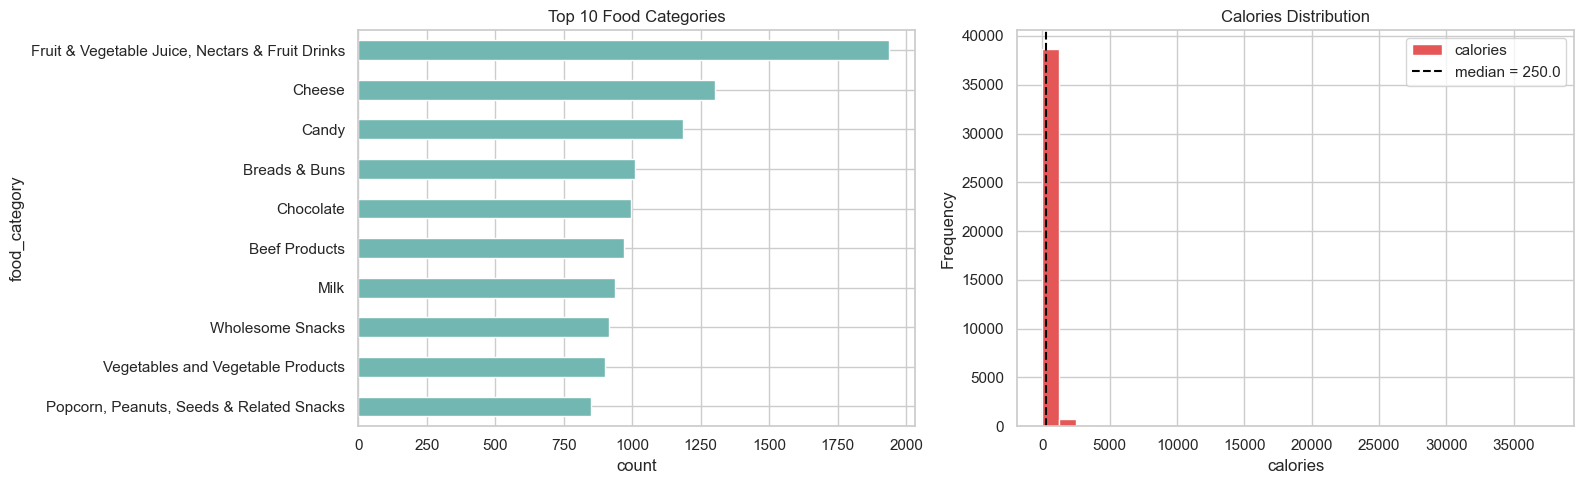

In [12]:
if plt is None:
    print("matplotlib is not installed; skipping charts.")
else:
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))

    (
        food_df[food_category_col]
        .fillna("Unknown")
        .value_counts()
        .head(10)
        .sort_values()
        .plot(kind="barh", ax=axes[0], color="#72B7B2")
    )
    axes[0].set_title("Top 10 Food Categories")
    axes[0].set_xlabel("count")

    food_df["calories"].dropna().plot(kind="hist", bins=30, ax=axes[1], color="#E45756")
    axes[1].axvline(food_df["calories"].median(), color="black", linestyle="--", label=f"median = {food_df['calories'].median():.1f}")
    axes[1].set_title("Calories Distribution")
    axes[1].set_xlabel("calories")
    axes[1].legend()

    plt.tight_layout()
    plt.show()


In [13]:
artifact_summary = pd.DataFrame([
    {"artifact": "knowledge_tables", "value": len(knowledge_tables)},
    {"artifact": "knowledge_bundle_json", "value": (KNOWLEDGE_DIR / "knowledge_bundle.json").exists()},
    {"artifact": "food_dataset", "value": food_path.name},
    {"artifact": "food_rows", "value": int(food_df.shape[0])},
    {"artifact": "food_columns", "value": int(food_df.shape[1])},
])

display(artifact_summary)


,artifact,value
0,knowledge_tables,6
1,knowledge_bundle_json,True
2,food_dataset,Food Nutri.csv
3,food_rows,40000
4,food_columns,24
